In [1]:
import warnings

# notebook display options
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
from analysis_utils_msr import sort_mutations_by_position

results = {}
for dataset in ['domainome']: 
    print(dataset)

    df_ts_1 = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_feb19_tsuboyama_new1_epoch=99_val_ddG_spearman=0.71.ckpt.csv', index_col=0)
    df_ts_1['ThermoMPNN_1'] = df_ts_1['ddG_pred']
    df_ts_2 = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_feb19_tsuboyama_new2_epoch=99_val_ddG_spearman=0.71.ckpt.csv', index_col=0)
    df_ts_2['ThermoMPNN_2'] = df_ts_2['ddG_pred']
    df_ts_3 = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/thermompnnd/single_feb19_tsuboyama_new3_epoch=98_val_ddG_spearman=0.7.ckpt.csv', index_col=0)
    df_ts_3['ThermoMPNN_3'] = df_ts_3['ddG_pred']

    df_thermo = df_ts_1[['code', 'mut_type', 'ThermoMPNN_1', 'ddG_true']].join(df_ts_2[['ThermoMPNN_2']], how='inner').join(df_ts_3[['ThermoMPNN_3']], how='inner')
    df_thermo = df_thermo.rename({'ddG_true': 'ddG_ML_thermo'}, axis=1)

    df_me_1 = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/dms_new1_feb19_tsuboyama_checkpoint-99.csv', index_col=0)
    df_me_1['MutateEverything_1'] = df_me_1['ddG_pred']
    df_me_1['ddG_ML_me'] = df_me_1['ddG_true']
    df_me_2 = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/dms_new2_feb19_tsuboyama_checkpoint-99.csv', index_col=0)
    df_me_2['MutateEverything_2'] = df_me_2['ddG_pred']
    df_me_3 = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/mutate_everything/dms_new3_feb19_tsuboyama_checkpoint-99.csv', index_col=0)
    df_me_3['MutateEverything_3'] = df_me_3['ddG_pred']

    df_me = df_me_1[['code', 'mut_type', 'MutateEverything_1', 'ddG_ML_me']].join(df_me_2[['MutateEverything_2']], how='inner').join(df_me_3[['MutateEverything_3']], how='inner')
    if dataset in 'domainome':
        df_me.index = df_me['code'].str.rstrip('A') + '_' + df_me['mut_type']
    assert len(df_me) == len(df_me_1)

    df_zero_sm = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/zero_shot/esm3-small-2024-08_masked.csv', index_col=0).rename({'esm3_score': 'ESM3-small', 'additive_score': 'ESM3-small_additive'}, axis=1)
    df_zero_med = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/zero_shot/esm3-medium-2024-08_masked.csv', index_col=0).rename({'esm3_score': 'ESM3-medium', 'additive_score': 'ESM3-medium_additive'}, axis=1)
    df_zero_lg = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/zero_shot/esm3-large-2024-03_masked.csv', index_col=0).rename({'esm3_score': 'ESM3-large', 'additive_score': 'ESM3-large_additive'}, axis=1)

    df_mpnn = pd.read_csv(f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}/proteinmpnn/proteinmpnn_020_chain.csv', index_col=0).rename({'mpnn_score': 'ProteinMPNN'}, axis=1)
    if dataset == 'domainome':
        df_mpnn = df_mpnn.reset_index(drop=True)
        df_mpnn['uid'] = df_mpnn['code'] + '_' + df_mpnn['mut_type']
        df_mpnn = df_mpnn.set_index('uid')
        
    df_ros = pd.DataFrame()

    df = \
        df_zero_sm[[c for c in df_zero_sm.columns if 'ESM3' in c]].join(
        df_thermo[[c for c in df_thermo.columns if 'ThermoMPNN' in c] + ['ddG_ML_thermo']], how='left').join(
        df_me[[c for c in df_me.columns if 'MutateEverything' in c] + ['ddG_ML_me']], how='left').join(
        #df_esm[[c for c in df_esm.columns if 'ESM-MSR' in c] + ['ddG_ML_esm', 'code', 'mut_type']], how='left').join(
        df_zero_med[[c for c in df_zero_med.columns if 'ESM3' in c]], how='left').join(
        df_zero_lg[[c for c in df_zero_lg.columns if 'ESM3' in c]], how='left').join(
        #df_ros[[c for c in df_ros.columns if 'Rosetta' in c]], how='left').join(
        df_mpnn[[c for c in df_mpnn.columns if 'ProteinMPNN' in c]], how='left'
        )

    truth = 'ddG_ML'
    get_additive = False

    df_esm_1 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/1/epoch=08-val_rho_avg=0.758.ckpt_alpha12chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_1.columns:
        df_esm_1['mut_type'] = df_esm_1['mut_info']
    df_esm_1['ESM-MSR_1'] = df_esm_1['ddg_pred']
    df_esm_1['ddG_ML_esm'] = df_esm_1[truth]
    df_esm_2 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/2/epoch=07-val_rho_avg=0.755.ckpt_alpha12chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_2.columns:
        df_esm_2['mut_type'] = df_esm_2['mut_info']
    df_esm_2['ESM-MSR_2'] = df_esm_2['ddg_pred']
    df_esm_3 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/3/epoch=08-val_rho_avg=0.757.ckpt_alpha12chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_3.columns:
        df_esm_3['mut_type'] = df_esm_3['mut_info']
    df_esm_3['ESM-MSR_3'] = df_esm_3['ddg_pred']
    df_esm = pd.concat([df_esm_1.reset_index(), df_esm_2[[c for c in df_esm_2.columns if 'MSR' in c]].reset_index(drop=True), df_esm_3[[c for c in df_esm_3.columns if 'MSR' in c]].reset_index(drop=True)], axis=1)

    df_esm['prefix'] = df_esm['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    if dataset == 'domainome': df_esm['prefix'] = df_esm['code']
    df_esm['mut_info'] = df_esm['id'].apply(lambda x: x.split('_')[-1])
    df_esm = sort_mutations_by_position(df_esm, 'mut_info', 'mut_type')
    df_esm['uid'] = df_esm['prefix'] + '_' + df_esm['mut_type']
    df_esm = df_esm.set_index('uid')
    df_esm = df_esm[~df_esm.index.duplicated()]

    df_esm_alpha10_1 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/1/epoch=08-val_rho_avg=0.758.ckpt_alpha10chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_alpha10_1.columns:
        df_esm_alpha10_1['mut_type'] = df_esm_alpha10_1['mut_info']
    df_esm_alpha10_1['ESM-MSR_alpha10_1'] = df_esm_alpha10_1['ddg_pred']
    if get_additive:
        df_esm_alpha10_1.loc[~df_esm_alpha10_1['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_alpha10_1.loc[~df_esm_alpha10_1['mut_info'].str.contains(':'), 'ddg_pred']
        df_esm_alpha10_1['ESM-MSR_alpha10_additive_1'] = df_esm_alpha10_1['ddg_pred_additive']
    df_esm_alpha10_2 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/2/epoch=07-val_rho_avg=0.755.ckpt_alpha10chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_alpha10_2.columns:
        df_esm_alpha10_2['mut_type'] = df_esm_alpha10_2['mut_info']
    df_esm_alpha10_2['ESM-MSR_alpha10_2'] = df_esm_alpha10_2['ddg_pred']
    if get_additive:
        df_esm_alpha10_2.loc[~df_esm_alpha10_2['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_alpha10_2.loc[~df_esm_alpha10_2['mut_info'].str.contains(':'), 'ddg_pred']
        df_esm_alpha10_2['ESM-MSR_alpha10_additive_2'] = df_esm_alpha10_2['ddg_pred_additive']
    df_esm_alpha10_3 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/3/epoch=08-val_rho_avg=0.757.ckpt_alpha10chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_alpha10_3.columns:
        df_esm_alpha10_3['mut_type'] = df_esm_alpha10_3['mut_info']
    df_esm_alpha10_3['ESM-MSR_alpha10_3'] = df_esm_alpha10_3['ddg_pred']
    if get_additive:
        df_esm_alpha10_3.loc[~df_esm_alpha10_3['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_alpha10_3.loc[~df_esm_alpha10_3['mut_info'].str.contains(':'), 'ddg_pred']
        df_esm_alpha10_3['ESM-MSR_alpha10_additive_3'] = df_esm_alpha10_3['ddg_pred_additive']
    df_esm_alpha10 = pd.concat([df_esm_alpha10_1.reset_index(), df_esm_alpha10_2[[c for c in df_esm_alpha10_2.columns if 'MSR' in c]].reset_index(drop=True), df_esm_alpha10_3[[c for c in df_esm_alpha10_3.columns if 'MSR' in c]].reset_index(drop=True)], axis=1)

    df_esm_alpha10['prefix'] = df_esm_alpha10['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    if dataset == 'domainome': df_esm_alpha10['prefix'] = df_esm_alpha10['code']
    df_esm_alpha10['mut_info'] = df_esm_alpha10['id'].apply(lambda x: x.split('_')[-1])
    df_esm_alpha10 = sort_mutations_by_position(df_esm_alpha10, 'mut_info', 'mut_type')
    df_esm_alpha10['uid'] = df_esm_alpha10['prefix'] + '_' + df_esm_alpha10['mut_type']
    df_esm_alpha10 = df_esm_alpha10.set_index('uid')
    df_esm_alpha10 = df_esm_alpha10[~df_esm_alpha10.index.duplicated()]

    df_esm_alpha8_1 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/1/epoch=08-val_rho_avg=0.758.ckpt_alpha8chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_alpha8_1.columns:
        df_esm_alpha8_1['mut_type'] = df_esm_alpha8_1['mut_info']
    df_esm_alpha8_1['ESM-MSR_alpha8_1'] = df_esm_alpha8_1['ddg_pred']
    if get_additive:
        df_esm_alpha8_1.loc[~df_esm_alpha8_1['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_alpha8_1.loc[~df_esm_alpha8_1['mut_info'].str.contains(':'), 'ddg_pred']
        df_esm_alpha8_1['ESM-MSR_alpha8_additive_1'] = df_esm_alpha8_1['ddg_pred_additive']
    df_esm_alpha8_2 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/2/epoch=07-val_rho_avg=0.755.ckpt_alpha8chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_alpha8_2.columns:
        df_esm_alpha8_2['mut_type'] = df_esm_alpha8_2['mut_info']
    df_esm_alpha8_2['ESM-MSR_alpha8_2'] = df_esm_alpha8_2['ddg_pred']
    if get_additive:
        df_esm_alpha8_2.loc[~df_esm_alpha8_2['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_alpha8_2.loc[~df_esm_alpha8_2['mut_info'].str.contains(':'), 'ddg_pred']
        df_esm_alpha8_2['ESM-MSR_alpha8_additive_2'] = df_esm_alpha8_2['ddg_pred_additive']
    df_esm_alpha8_3 = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/3/epoch=08-val_rho_avg=0.757.ckpt_alpha8chain_rule_avg_masked.csv', index_col=0)
    if 'mut_type' not in df_esm_alpha8_3.columns:
        df_esm_alpha8_3['mut_type'] = df_esm_alpha8_3['mut_info']
    df_esm_alpha8_3['ESM-MSR_alpha8_3'] = df_esm_alpha8_3['ddg_pred']
    if get_additive:
        df_esm_alpha8_3.loc[~df_esm_alpha8_3['mut_info'].str.contains(':'), 'ddg_pred_additive'] = df_esm_alpha8_3.loc[~df_esm_alpha8_3['mut_info'].str.contains(':'), 'ddg_pred']
        df_esm_alpha8_3['ESM-MSR_alpha8_additive_3'] = df_esm_alpha8_3['ddg_pred_additive']
    df_esm_alpha8 = pd.concat([df_esm_alpha8_1.reset_index(), df_esm_alpha8_2[[c for c in df_esm_alpha8_2.columns if 'MSR' in c]].reset_index(drop=True), df_esm_alpha8_3[[c for c in df_esm_alpha8_3.columns if 'MSR' in c]].reset_index(drop=True)], axis=1)

    df_esm_alpha8['prefix'] = df_esm_alpha8['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    if dataset == 'domainome': df_esm_alpha8['prefix'] = df_esm_alpha8['code']
    df_esm_alpha8['mut_info'] = df_esm_alpha8['id'].apply(lambda x: x.split('_')[-1])
    df_esm_alpha8 = sort_mutations_by_position(df_esm_alpha8, 'mut_info', 'mut_type')
    df_esm_alpha8['uid'] = df_esm_alpha8['prefix'] + '_' + df_esm_alpha8['mut_type']
    df_esm_alpha8 = df_esm_alpha8.set_index('uid')
    df_esm_alpha8 = df_esm_alpha8[~df_esm_alpha8.index.duplicated()]

    df_esm_zs = pd.read_csv(f'/home/sareeves/software/esm-msr/analysis_notebooks/predictions/{dataset}/msr_chain/1/epoch=08-val_rho_avg=0.758.ckpt_alpha0chain_rule_avg_masked.csv', index_col=0).sort_index()
    if 'mut_type' not in df_esm_zs.columns:
        df_esm_zs['mut_type'] = df_esm_zs['mut_info']
    df_esm_zs['ESM3-small-open'] = df_esm_zs['ddg_pred']
    if get_additive:
        df_esm_zs['ESM3-small-open_additive'] = df_esm_zs['ddg_pred_additive']
    df_esm_zs = df_esm_zs.reset_index()

    df_esm_zs['prefix'] = df_esm_zs['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    if dataset == 'domainome': df_esm_zs['prefix'] = df_esm_zs['code']
    df_esm_zs['mut_info'] = df_esm_zs['id'].apply(lambda x: x.split('_')[-1])
    df_esm_zs = sort_mutations_by_position(df_esm_zs, 'mut_info', 'mut_type')
    df_esm_zs['uid'] = df_esm_zs['prefix'] + '_' + df_esm_zs['mut_type']
    df_esm_zs = df_esm_zs.set_index('uid')
    df_esm_zs = df_esm_zs[~df_esm_zs.index.duplicated()]

    df = df.join(df_esm[[c for c in df_esm.columns if 'MSR' in c]+['code', 'mut_type', 'ddG_ML_esm']], how='left')
    df = df.join(df_esm_alpha10[[c for c in df_esm_alpha10.columns if 'MSR' in c]], how='left')
    df = df.join(df_esm_alpha8[[c for c in df_esm_alpha8.columns if 'MSR' in c]], how='left')
    df = df.join(df_esm_zs[['ESM3-small-open'] + (['ESM3-small-open_additive'] if get_additive else [])], how='left')

    results['domainome'] = df

domainome


In [3]:
df.dropna(subset=['ddG_ML_esm'])

,ESM3-small,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ddG_ML_thermo,MutateEverything_1,MutateEverything_2,MutateEverything_3,ddG_ML_me,ESM3-medium,...,code,mut_type,ddG_ML_esm,ESM-MSR_alpha10_1,ESM-MSR_alpha10_2,ESM-MSR_alpha10_3,ESM-MSR_alpha8_1,ESM-MSR_alpha8_2,ESM-MSR_alpha8_3,ESM3-small-open
id,,,,,,,,,,,,,,,,,,,,,
A0A2R8Y422_PF00240_2_A27C,-4.277344,0.163495,0.164747,0.180591,0.025738,-0.277289,0.079261,-0.090177,0.025738,-6.257812,...,A0A2R8Y422_PF00240_2,A27C,0.025738,-0.255130,-0.392973,-0.272083,-0.659980,-0.817607,-0.697174,-1.726670
A0A2R8Y422_PF00240_2_A27D,-7.765625,-1.080735,-0.948103,-1.055444,0.111544,-0.774795,-0.500648,-0.427810,0.111544,-5.273926,...,A0A2R8Y422_PF00240_2,A27D,0.111544,-1.362043,-1.606409,-1.486822,-1.763522,-1.973307,-1.864083,-2.016993
A0A2R8Y422_PF00240_2_A27E,-5.070312,-0.670931,-0.453918,-0.478028,0.290325,-0.372168,-0.205457,-0.060037,0.290325,-5.276855,...,A0A2R8Y422_PF00240_2,A27E,0.290325,-0.926709,-1.173960,-1.059638,-1.355452,-1.569992,-1.469483,-1.632443
A0A2R8Y422_PF00240_2_A27F,-6.578125,0.042895,-0.034506,-0.133016,0.002225,-0.299222,-0.256217,-0.083315,0.002225,-6.257812,...,A0A2R8Y422_PF00240_2,A27F,0.002225,-0.755331,-0.966385,-0.788799,-1.234110,-1.451638,-1.273080,-1.945087
A0A2R8Y422_PF00240_2_A27G,-4.585938,-0.654465,-0.562278,-0.446236,-0.033329,-0.343350,-0.454239,-0.609559,-0.033329,-5.779297,...,A0A2R8Y422_PF00240_2,A27G,-0.033329,-1.054942,-1.231317,-1.100593,-1.384215,-1.529327,-1.417169,-1.756332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Y6N9_PF00595_207_V83R,-1.890625,-0.073726,-0.061115,0.093025,0.040825,-0.363254,-0.472367,-0.357397,0.040825,-0.390625,...,Q9Y6N9_PF00595_207,V83R,0.040825,-0.386809,-0.384780,-0.408698,-0.420666,-0.431363,-0.443525,-0.450926
Q9Y6N9_PF00595_207_V83S,-4.453125,-0.886565,-0.790380,-0.773277,-0.228931,-0.946277,-1.050818,-1.027597,-0.228931,-3.318359,...,Q9Y6N9_PF00595_207,V83S,-0.228931,-0.919069,-0.872764,-0.923920,-1.089098,-1.072904,-1.104030,-1.205647
Q9Y6N9_PF00595_207_V83T,-3.330078,-0.475408,-0.493150,-0.288942,-0.353383,-0.228972,-0.283794,-0.455571,-0.353383,-4.052734,...,Q9Y6N9_PF00595_207,V83T,-0.353383,-0.716251,-0.697831,-0.733776,-0.841619,-0.844844,-0.864132,-1.041797


In [4]:
df.dropna(subset=['ThermoMPNN_1', 'MutateEverything_1', 'ESM-MSR_1'])

,ESM3-small,ThermoMPNN_1,ThermoMPNN_2,ThermoMPNN_3,ddG_ML_thermo,MutateEverything_1,MutateEverything_2,MutateEverything_3,ddG_ML_me,ESM3-medium,...,code,mut_type,ddG_ML_esm,ESM-MSR_alpha10_1,ESM-MSR_alpha10_2,ESM-MSR_alpha10_3,ESM-MSR_alpha8_1,ESM-MSR_alpha8_2,ESM-MSR_alpha8_3,ESM3-small-open
id,,,,,,,,,,,,,,,,,,,,,
A0A2R8Y422_PF00240_2_A27C,-4.277344,0.163495,0.164747,0.180591,0.025738,-0.277289,0.079261,-0.090177,0.025738,-6.257812,...,A0A2R8Y422_PF00240_2,A27C,0.025738,-0.255130,-0.392973,-0.272083,-0.659980,-0.817607,-0.697174,-1.726670
A0A2R8Y422_PF00240_2_A27D,-7.765625,-1.080735,-0.948103,-1.055444,0.111544,-0.774795,-0.500648,-0.427810,0.111544,-5.273926,...,A0A2R8Y422_PF00240_2,A27D,0.111544,-1.362043,-1.606409,-1.486822,-1.763522,-1.973307,-1.864083,-2.016993
A0A2R8Y422_PF00240_2_A27E,-5.070312,-0.670931,-0.453918,-0.478028,0.290325,-0.372168,-0.205457,-0.060037,0.290325,-5.276855,...,A0A2R8Y422_PF00240_2,A27E,0.290325,-0.926709,-1.173960,-1.059638,-1.355452,-1.569992,-1.469483,-1.632443
A0A2R8Y422_PF00240_2_A27F,-6.578125,0.042895,-0.034506,-0.133016,0.002225,-0.299222,-0.256217,-0.083315,0.002225,-6.257812,...,A0A2R8Y422_PF00240_2,A27F,0.002225,-0.755331,-0.966385,-0.788799,-1.234110,-1.451638,-1.273080,-1.945087
A0A2R8Y422_PF00240_2_A27G,-4.585938,-0.654465,-0.562278,-0.446236,-0.033329,-0.343350,-0.454239,-0.609559,-0.033329,-5.779297,...,A0A2R8Y422_PF00240_2,A27G,-0.033329,-1.054942,-1.231317,-1.100593,-1.384215,-1.529327,-1.417169,-1.756332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Y6N9_PF00595_207_V83R,-1.890625,-0.073726,-0.061115,0.093025,0.040825,-0.363254,-0.472367,-0.357397,0.040825,-0.390625,...,Q9Y6N9_PF00595_207,V83R,0.040825,-0.386809,-0.384780,-0.408698,-0.420666,-0.431363,-0.443525,-0.450926
Q9Y6N9_PF00595_207_V83S,-4.453125,-0.886565,-0.790380,-0.773277,-0.228931,-0.946277,-1.050818,-1.027597,-0.228931,-3.318359,...,Q9Y6N9_PF00595_207,V83S,-0.228931,-0.919069,-0.872764,-0.923920,-1.089098,-1.072904,-1.104030,-1.205647
Q9Y6N9_PF00595_207_V83T,-3.330078,-0.475408,-0.493150,-0.288942,-0.353383,-0.228972,-0.283794,-0.455571,-0.353383,-4.052734,...,Q9Y6N9_PF00595_207,V83T,-0.353383,-0.716251,-0.697831,-0.733776,-0.841619,-0.844844,-0.864132,-1.041797


In [5]:
import numpy as np
from analysis_utils_msr import compute_stats_multi

for name, df in results.items():
    print(name)

    df['ddG'] = df['ddG_ML_esm']
    df['upper_bound'] = df['ddG']
    df['random_1'] = np.random.normal(loc=0, size=len(df))
    df['random_2'] = np.random.normal(loc=0, size=len(df))
    df['random_3'] = np.random.normal(loc=0, size=len(df))
    df = df.drop('mut_type', axis=1)
    df.columns = [c+'_dir' if c not in ['code', 'ddG'] else c for c in df.columns]
    df['fake_grouper'] = 1
    curve_df_ungrouped = compute_stats_multi(df.dropna(how='all', axis=1).drop('code', axis=1), stats=('aumsc', 'auppc'), measurements=['ddG'], grouper='fake_grouper', n_bootstraps=0, threshold=0)

# 3 hours

domainome


  0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
for name, df in results.items():
    print(name)

    df['ddG'] = df['ddG_ML_esm']
    df['upper_bound'] = df['ddG']
    df['random_1'] = np.random.normal(loc=0, size=len(df))
    df['random_2'] = np.random.normal(loc=0, size=len(df))
    df['random_3'] = np.random.normal(loc=0, size=len(df))
    df = df.drop('mut_type', axis=1)
    df.columns = [c+'_dir' if c not in ['code', 'ddG'] else c for c in df.columns]
    df['fake_grouper'] = 1
    curve_df_grouped = compute_stats_multi(df.dropna(how='all', axis=1), stats=('aumsc', 'auppc'), measurements=['ddG'], grouper='code', n_bootstraps=0, threshold=0)

# 3 hours

#stats_df_full = compute_stats_multi(df.dropna(how='all', axis=1).drop('code', axis=1), measurements=['ddG'], grouper='fake_grouper', n_bootstraps=0, threshold=0)

domainome


  0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
def annotate_points(ax, data, x_col, y_col, hue_col, x_values, text_offset=(0, 0), spacing=0.02):
    line_colors = {}
    for line in ax.lines:
        label = line.get_label()
        color = line.get_color()
        line_colors[label] = color

    for x_val in x_values:
        models_and_points = []
        for model, model_data in data.groupby(hue_col):
            value_row = model_data.loc[model_data[x_col] == x_val]
            if not value_row.empty:
                if len(value_row) > 1:
                    x, y = value_row[x_col].values[0], value_row[y_col].values.mean()
                else:
                    x, y = value_row[x_col].values[0], value_row[y_col].values[0]
                models_and_points.append((model, x, y))

        # Sort models_and_points by y values to space them evenly
        models_and_points = sorted(models_and_points, key=lambda x: x[2], reverse=True)
        print(models_and_points)

        # Calculate annotation positions and add annotations
        y_annot = max(y for _, _, y in models_and_points) + text_offset[1]
        for model, x, y in models_and_points:
            ax.annotate(f"{y:.2f}", (x, y),
                        xytext=(x + text_offset[0], y_annot),
                        arrowprops=dict(arrowstyle='-', lw=1, color='gray'),
                        fontsize=12, color=line_colors[model])
            y_annot -= spacing
            ax.axvline(x=x, color='r', linestyle='dashed')

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re

def recovery_curves(rcv, models=['cartesian_ddg', 'ddG', 'dTm', 'random'], measurements=('ddG'), plots=('auppc', 'aumsc'), title='Dataset'):

    font = {'size': 12}
    matplotlib.rc('font', **font)

    if len(plots) == 1:
        if len(measurements) == 1:
            fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)
            ax_list = [axes]  
        else:
            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=300)
            ax_list = [axes[0], axes[1]]        
    elif len(plots) == 2:
        if len(measurements) == 1:
            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=300)
            ax_list = [axes[0], axes[1]]
        else:
            fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12), dpi=300)
            ax_list = [axes[0, 0], axes[1, 0], axes[0, 1], axes[1, 1]]

    d5 = rcv.reset_index()
    d5 = d5.loc[d5['model'].isin(models)].set_index(['measurement', 'model_type', 'model', 'class'])
    d5 = d5.drop([c for c in d5.columns if 'stab_' in c], axis=1)

    # Function to extract base model name (removing numeric suffixes)
    def get_base_model_name(model_name):
        # Match patterns like "model_name_1", "model_name_2.0", etc.
        match = re.match(r'^(.*?)_\d+(.*)?$', model_name)
        if match:
            full_match = match.group(1)
            if match.group(2):
                full_match += match.group(2)
            return full_match
        return model_name

    i = 0

    if 'ddG' in measurements:
        # for plotting recovery over thresholds
        if 'auppc' in plots:
            recov = d5[[c for c in d5.columns if '%' in c]].reset_index()
            recov = recov.loc[recov['model'] != 'dTm']
            recov = recov.loc[recov['measurement'] == 'ddG']
            recov = recov.drop(['measurement', 'model_type', 'class'], axis=1)
            
            # Add base model column
            recov['base_model'] = recov['model'].apply(get_base_model_name)
            
            # Process data
            melted_1 = recov.melt(id_vars=['model', 'base_model'], value_vars=[c for c in recov.columns if c not in ['model', 'base_model']], 
                                  var_name="variable", value_name="value")
            recov = melted_1
            recov['variable'] = recov['variable'].str.strip('%').astype(float)
            
            # Sort random to the end
            recov['sort_helper'] = recov['model'] == 'random'
            recov = recov.sort_values(by='sort_helper').drop('sort_helper', axis=1)
            
            # Get unique base models to plot
            unique_base_models = sorted(recov['base_model'].unique().tolist())
            if 'random' in unique_base_models:
                unique_base_models.remove('random')
                unique_base_models.append('random')  # Move to end
            
            cmap = get_color_mapping(pd.DataFrame({'model': unique_base_models}), 'model')
            print(cmap)
            
            # For each base model, calculate mean and std
            for base_model in unique_base_models:
                subset = recov[recov['base_model'] == base_model]
                
                # Group by variable and calculate mean and std
                grouped = subset.groupby('variable').agg({'value': ['mean', 'std']})
                grouped.columns = ['mean', 'std']
                grouped = grouped.reset_index()
                
                color = cmap[base_model]
                
                # Plot mean line
                ax_ = sns.lineplot(data=grouped, x='variable', y='mean', ax=ax_list[i], 
                                  label=base_model, color=color)
                
                # Add shaded area for standard deviation
                if len(subset['model'].unique()) > 1:  # Only add std if we have more than one model in the group
                    ax_list[i].fill_between(grouped['variable'], 
                                          grouped['mean'] - grouped['std'],
                                          grouped['mean'] + grouped['std'], 
                                          alpha=0.2, color=color)
                
                # Special handling for zero shot
                if 'esm3' in base_model:
                    ax_.lines[-1].set_linestyle('--')

                # Special handling for MSR
                if 'esm_msr' in base_model:
                    ax_.lines[-1].set_linestyle('-')

                # Special handling for random
                if 'random' in base_model:
                    ax_.lines[-1].set_linestyle('--')

            if len(measurements) > 1:
                ax_list[i].set_xlabel('')
            else:
                ax_list[i].set_xlabel('top x% of ranked predictions')
            ax_list[i].set_ylabel('fraction higher-than-wildtype abundance')
            #annotate_points(ax_list[i], recov, 'variable', 'value', 'model', points, text_offset=left_text_offset, spacing=left_spacing/2)
            i += 1

        if 'aumsc' in plots:
            recov = d5[[c for c in d5.columns if '$' in c]].reset_index()
            recov = recov.loc[recov['model'] != 'dTm']
            recov = recov.loc[recov['measurement'] == 'ddG']
            recov = recov.drop(['measurement', 'model_type', 'class'], axis=1)
            
            # Add base model column
            recov['base_model'] = recov['model'].apply(get_base_model_name)
            
            # Process data
            recov = recov.melt(id_vars=['model', 'base_model'], var_name="variable", value_name="value")
            recov['variable'] = recov['variable'].str.strip('$').astype(float)
            
            # Sort random to the end
            recov['sort_helper'] = recov['model'] == 'random'
            recov = recov.sort_values(by='sort_helper').drop('sort_helper', axis=1)
            
            # Get unique base models to plot
            unique_base_models = sorted(recov['base_model'].unique().tolist())
            if 'random' in unique_base_models:
                unique_base_models.remove('random')
                unique_base_models.append('random')  # Move to end
            
            cmap = get_color_mapping(pd.DataFrame({'model': unique_base_models}), 'model')
            if not cmap:
                cmap = get_color_mapping(pd.DataFrame({'model': unique_base_models}), 'model')
            
            # For each base model, calculate mean and std
            for base_model in unique_base_models:
                subset = recov[recov['base_model'] == base_model]
                
                # Group by variable and calculate mean and std
                grouped = subset.groupby('variable').agg({'value': ['mean', 'std']})
                grouped.columns = ['mean', 'std']
                grouped = grouped.reset_index()
                
                color = cmap[base_model]
                
                # Plot mean line
                ax_ = sns.lineplot(data=grouped, x='variable', y='mean', ax=ax_list[i], 
                                  label=base_model, color=color)
                
                # Add shaded area for standard deviation
                if len(subset['model'].unique()) > 1:  # Only add std if we have more than one model in the group
                    ax_list[i].fill_between(grouped['variable'], 
                                          grouped['mean'] - grouped['std'],
                                          grouped['mean'] + grouped['std'], 
                                          alpha=0.2, color=color)

                # Special handling for zero shot
                if 'esm3' in base_model:
                    ax_.lines[-1].set_linestyle('--')

                # Special handling for MSR
                if 'esm_msr' in base_model:
                    ax_.lines[-1].set_linestyle('-')

                # Special handling for random
                if 'random' in base_model:
                    ax_.lines[-1].set_linestyle('--')
                    
            ax_list[i].set_xlabel('top x% of ranked predictions')
            ax_list[i].set_ylabel('mean abundance increase')
            #annotate_points(ax_list[i], recov, 'variable', 'value', 'model', points, text_offset=right_text_offset, spacing=right_spacing*12)
            i += 1

    # Handle legends
    handles, labels = ax_list[0].get_legend_handles_labels()
    
    if len(ax_list) > 1:
        for ax in ax_list:
            try:
                ax.get_legend().remove()
                ax.set_title(title)
            except:
                pass
    else:
        try:
            ax_list[0].get_legend().remove()
            ax_list[0].set_title(title)
        except:
            pass

    try:
        labels = [remap_names[name] if name in remap_names.keys() else name for name in labels]
    except NameError:
        pass  # remap_names_2 not defined

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.), ncol=2)
    plt.tight_layout()

    plt.show()
    return fig

In [8]:
from analysis_utils_msr import *

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import matplotlib

def recovery_curves_aumsc(rcv, models=['cartesian_ddg', 'ddG', 'dTm', 'random'], measurements=('ddG'), title='Dataset', range_full=(0, 50), range_mag=(0, 1), colormap=None, ins_ylim=(-1, 2)):

    font = {'size': 12}
    matplotlib.rc('font', **font)

    # Setup single plot
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)

    # Create the inset axes in the upper right, occupying roughly 1/4 of the area
    ax_ins = ax.inset_axes([0.52, 0.52, 0.45, 0.45])

    d5 = rcv.reset_index()
    d5 = d5.loc[d5['model'].isin(models)].set_index(['measurement', 'model_type', 'model', 'class'])
    d5 = d5.drop([c for c in d5.columns if 'stab_' in c], axis=1)

    # Function to extract base model name
    def get_base_model_name(model_name):
        match = re.match(r'^(.*?)_\d+(.*)?$', model_name)
        if match:
            full_match = match.group(1)
            if match.group(2):
                full_match += match.group(2)
            return full_match
        return model_name

    # Data Processing for 'aumsc' ($ columns)
    recov = d5[[c for c in d5.columns if '$' in c]].reset_index()
    recov = recov.loc[recov['model'] != 'dTm']
    
    if 'ddG' in measurements:
        recov = recov.loc[recov['measurement'] == 'ddG']
    
    recov = recov.drop(['measurement', 'model_type', 'class'], axis=1)
    
    recov['base_model'] = recov['model'].apply(get_base_model_name)
    
    recov = recov.melt(id_vars=['model', 'base_model'], var_name="variable", value_name="value")
    recov['variable'] = recov['variable'].str.strip('$').astype(float)
    
    # Sort random to the end
    recov['sort_helper'] = recov['model'] == 'random'
    recov = recov.sort_values(by='sort_helper').drop('sort_helper', axis=1)
    
    unique_base_models = sorted(recov['base_model'].unique().tolist())
    if 'random' in unique_base_models:
        unique_base_models.remove('random')
        unique_base_models.append('random') 
    
    # --- Color Logic ---
    if colormap is None:
        # Fallback to original helper if no map provided
        cmap = {'ProteinMPNN': '#34495e', 
                'ThermoMPNN': '#3498db', 
                'MutateEverything': '#2ecc71', 
                'ESM3-small-open': '#888888', 
                'ESM3-small': '#e74c3c', 
                'ESM3-medium': '#9b59b6',
                'ESM3-large': '#f39c12',
                'Rosetta Cartesian DDG': '#1abc9c',
                'ESM-MSR': '#000000',
                'ESM-MSR_alpha10': '#444444',
                'ESM-MSR_alpha8': '#888888'
                }
    else:
        cmap = colormap

    # -------------------

    # Define plotting helper
    def plot_subset(target_ax, x_range):
        # Filter data for the requested range
        subset_range = recov[(recov['variable'] >= x_range[0]) & (recov['variable'] <= x_range[1])]
        
        for base_model in unique_base_models:
            subset = subset_range[subset_range['base_model'] == base_model]
            if subset.empty:
                continue
            
            # Group by variable and calculate mean and std
            grouped = subset.groupby('variable').agg({'value': ['mean', 'std']})
            grouped.columns = ['mean', 'std']
            grouped = grouped.reset_index()
            
            # Retrieve color safely (fallback to black if missing in manual map)
            color = cmap.get(base_model, '#dddddd')
            
            # Plot mean line
            ax_ = sns.lineplot(data=grouped, x='variable', y='mean', ax=target_ax, 
                               label=base_model, color=color, legend=False)
            
            # Add shaded area for standard deviation
            if len(subset['model'].unique()) > 1:
                target_ax.fill_between(grouped['variable'], 
                                       grouped['mean'] - grouped['std'],
                                       grouped['mean'] + grouped['std'], 
                                       alpha=0.2, color=color)
            
            # Apply styles
            line = ax_.lines[-1]
            #if 'esm3' in base_model:
            #    line.set_linestyle('--')
            #if 'esm_msr' in base_model:
            #    line.set_linestyle('-')
            if 'random' in base_model:
                line.set_linestyle('--')

    # 1. Plot Full Range
    plot_subset(ax, range_full)
    ax.set_xlabel('top x% of ranked predictions')
    ax.set_ylabel('mean normalized abundance increase')
    ax.set_title(title)

    # 2. Plot Inset (Mag Range)
    plot_subset(ax_ins, range_mag)
    ax_ins.set_xlabel('')
    ax_ins.set_ylabel('')
    ax_ins.set_ylim(ins_ylim)

    # Handle Legends
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    # Try remapping names if the global dictionary exists
    try:
        final_labels = [remap_names[name] if name in remap_names.keys() else name for name in by_label.keys()]
    except NameError:
        final_labels = list(by_label.keys())
    
    final_handles = list(by_label.values())

    fig.legend(final_handles, final_labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2)
    plt.tight_layout()

    plt.show()
    return fig

<Axes: >

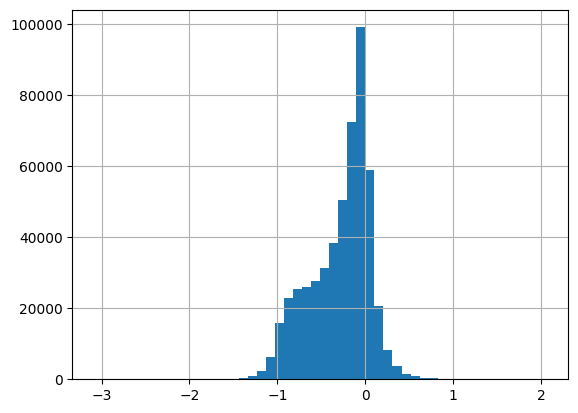

In [9]:
results['domainome']['ddG'].hist(bins=50)

In [10]:
curve_df_ungrouped

runtime      0.1%  \
measurement model_type  model                  class                      
ddG         potential   ThermoMPNN_1_dir                  NaN  0.437743   
                        ThermoMPNN_2_dir                  NaN  0.478599   
                        ThermoMPNN_3_dir                  NaN  0.464981   
            seq. PSLM   ESM3-large_dir                    NaN  0.482490   
                        ESM3-medium_dir                   NaN  0.556420   
                        ESM3-small-open_dir               NaN  0.570039   
                        ESM3-small_dir                    NaN  0.583658   
            struc. PSLM ProteinMPNN_dir                   NaN  0.603113   
            supervised  ESM-MSR_1_dir                     NaN  0.513619   
                        ESM-MSR_2_dir                     NaN  0.536965   
                        ESM-MSR_3_dir                     NaN  0.531128   
                        ESM-MSR_alpha10_1_dir             NaN  0.560311   
                        ESM-MSR_alpha10_2_dir             NaN  0.575875   
                        ESM-MSR_alpha10_3_dir             NaN  0.566148   
                        ESM-MSR_alpha8_1_dir              NaN  0.593385   
                        ESM-MSR_alpha8_2_dir              NaN  0.601167   
                        ESM-MSR_alpha8_3_dir              NaN  0.577821   
            transfer    MutateEverything_1_dir            NaN  0.394942   
                        MutateEverything_2_dir            NaN  0.379377   
                        MutateEverything_3_dir            NaN  0.408560   
            unknown     ddG_ML_esm_dir                    NaN  1.000000   
                        ddG_ML_me_dir                     NaN  1.000000   
                        ddG_ML_thermo_dir                 NaN  1.000000   
                        random_1_dir                      NaN  0.182879   
                        random_2_dir                      NaN  0.221790   
                        random_3_dir                      NaN  0.200389   
                        upper_bound_dir                   NaN  1.000000   

                                                          0.2%      0.3%  \
measurement model_type  model                  class                       
ddG         potential   ThermoMPNN_1_dir              0.417881  0.413480   
                        ThermoMPNN_2_dir              0.449951  0.423202   
                        ThermoMPNN_3_dir              0.425656  0.427090   
            seq. PSLM   ESM3-large_dir                0.509232  0.504861   
                        ESM3-medium_dir               0.577259  0.584576   
                        ESM3-small-open_dir           0.566569  0.566429   
                        ESM3-small_dir                0.593780  0.579391   
            struc. PSLM ProteinMPNN_dir               0.603499  0.599482   
            supervised  ESM-MSR_1_dir                 0.500486  0.504213   
                        ESM-MSR_2_dir                 0.519922  0.495139   
                        ESM-MSR_3_dir                 0.517979  0.501620   
                        ESM-MSR_alpha10_1_dir         0.553936  0.540506   
                        ESM-MSR_alpha10_2_dir         0.558795  0.544394   
                        ESM-MSR_alpha10_3_dir         0.549077  0.545042   
                        ESM-MSR_alpha8_1_dir          0.581147  0.561244   
                        ESM-MSR_alpha8_2_dir          0.580175  0.559948   
                        ESM-MSR_alpha8_3_dir          0.574344  0.566429   
            transfer    MutateEverything_1_dir        0.390671  0.386261   
                        MutateEverything_2_dir        0.370262  0.358393   
                        MutateEverything_3_dir        0.386783  0.379132   
            unknown     ddG_ML_esm_dir                1.000000  1.000000   
                        ddG_ML_me_dir                 1.000000  1.000000   
                        ddG_ML_thermo_dir             

{'ESM-MSR': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), 'ESM-MSR_alpha8': (0.9899427176361898, 0.7049211603598974, 0.8225918660182985), 'ESM3-large': (1.0, 0.4980392156862745, 0.054901960784313725), 'ESM3-medium': (1.0, 0.7258134136044577, 0.34937220016014536), 'ESM3-small': (0.643648132712171, 0.45921290515410135, 0.08082684463604409), 'MutateEverything': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'ProteinMPNN': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'ThermoMPNN': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'upper_bound': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), 'random': (0.7265158293962721, 0.7265262613414029, 0.6464853211708125)}


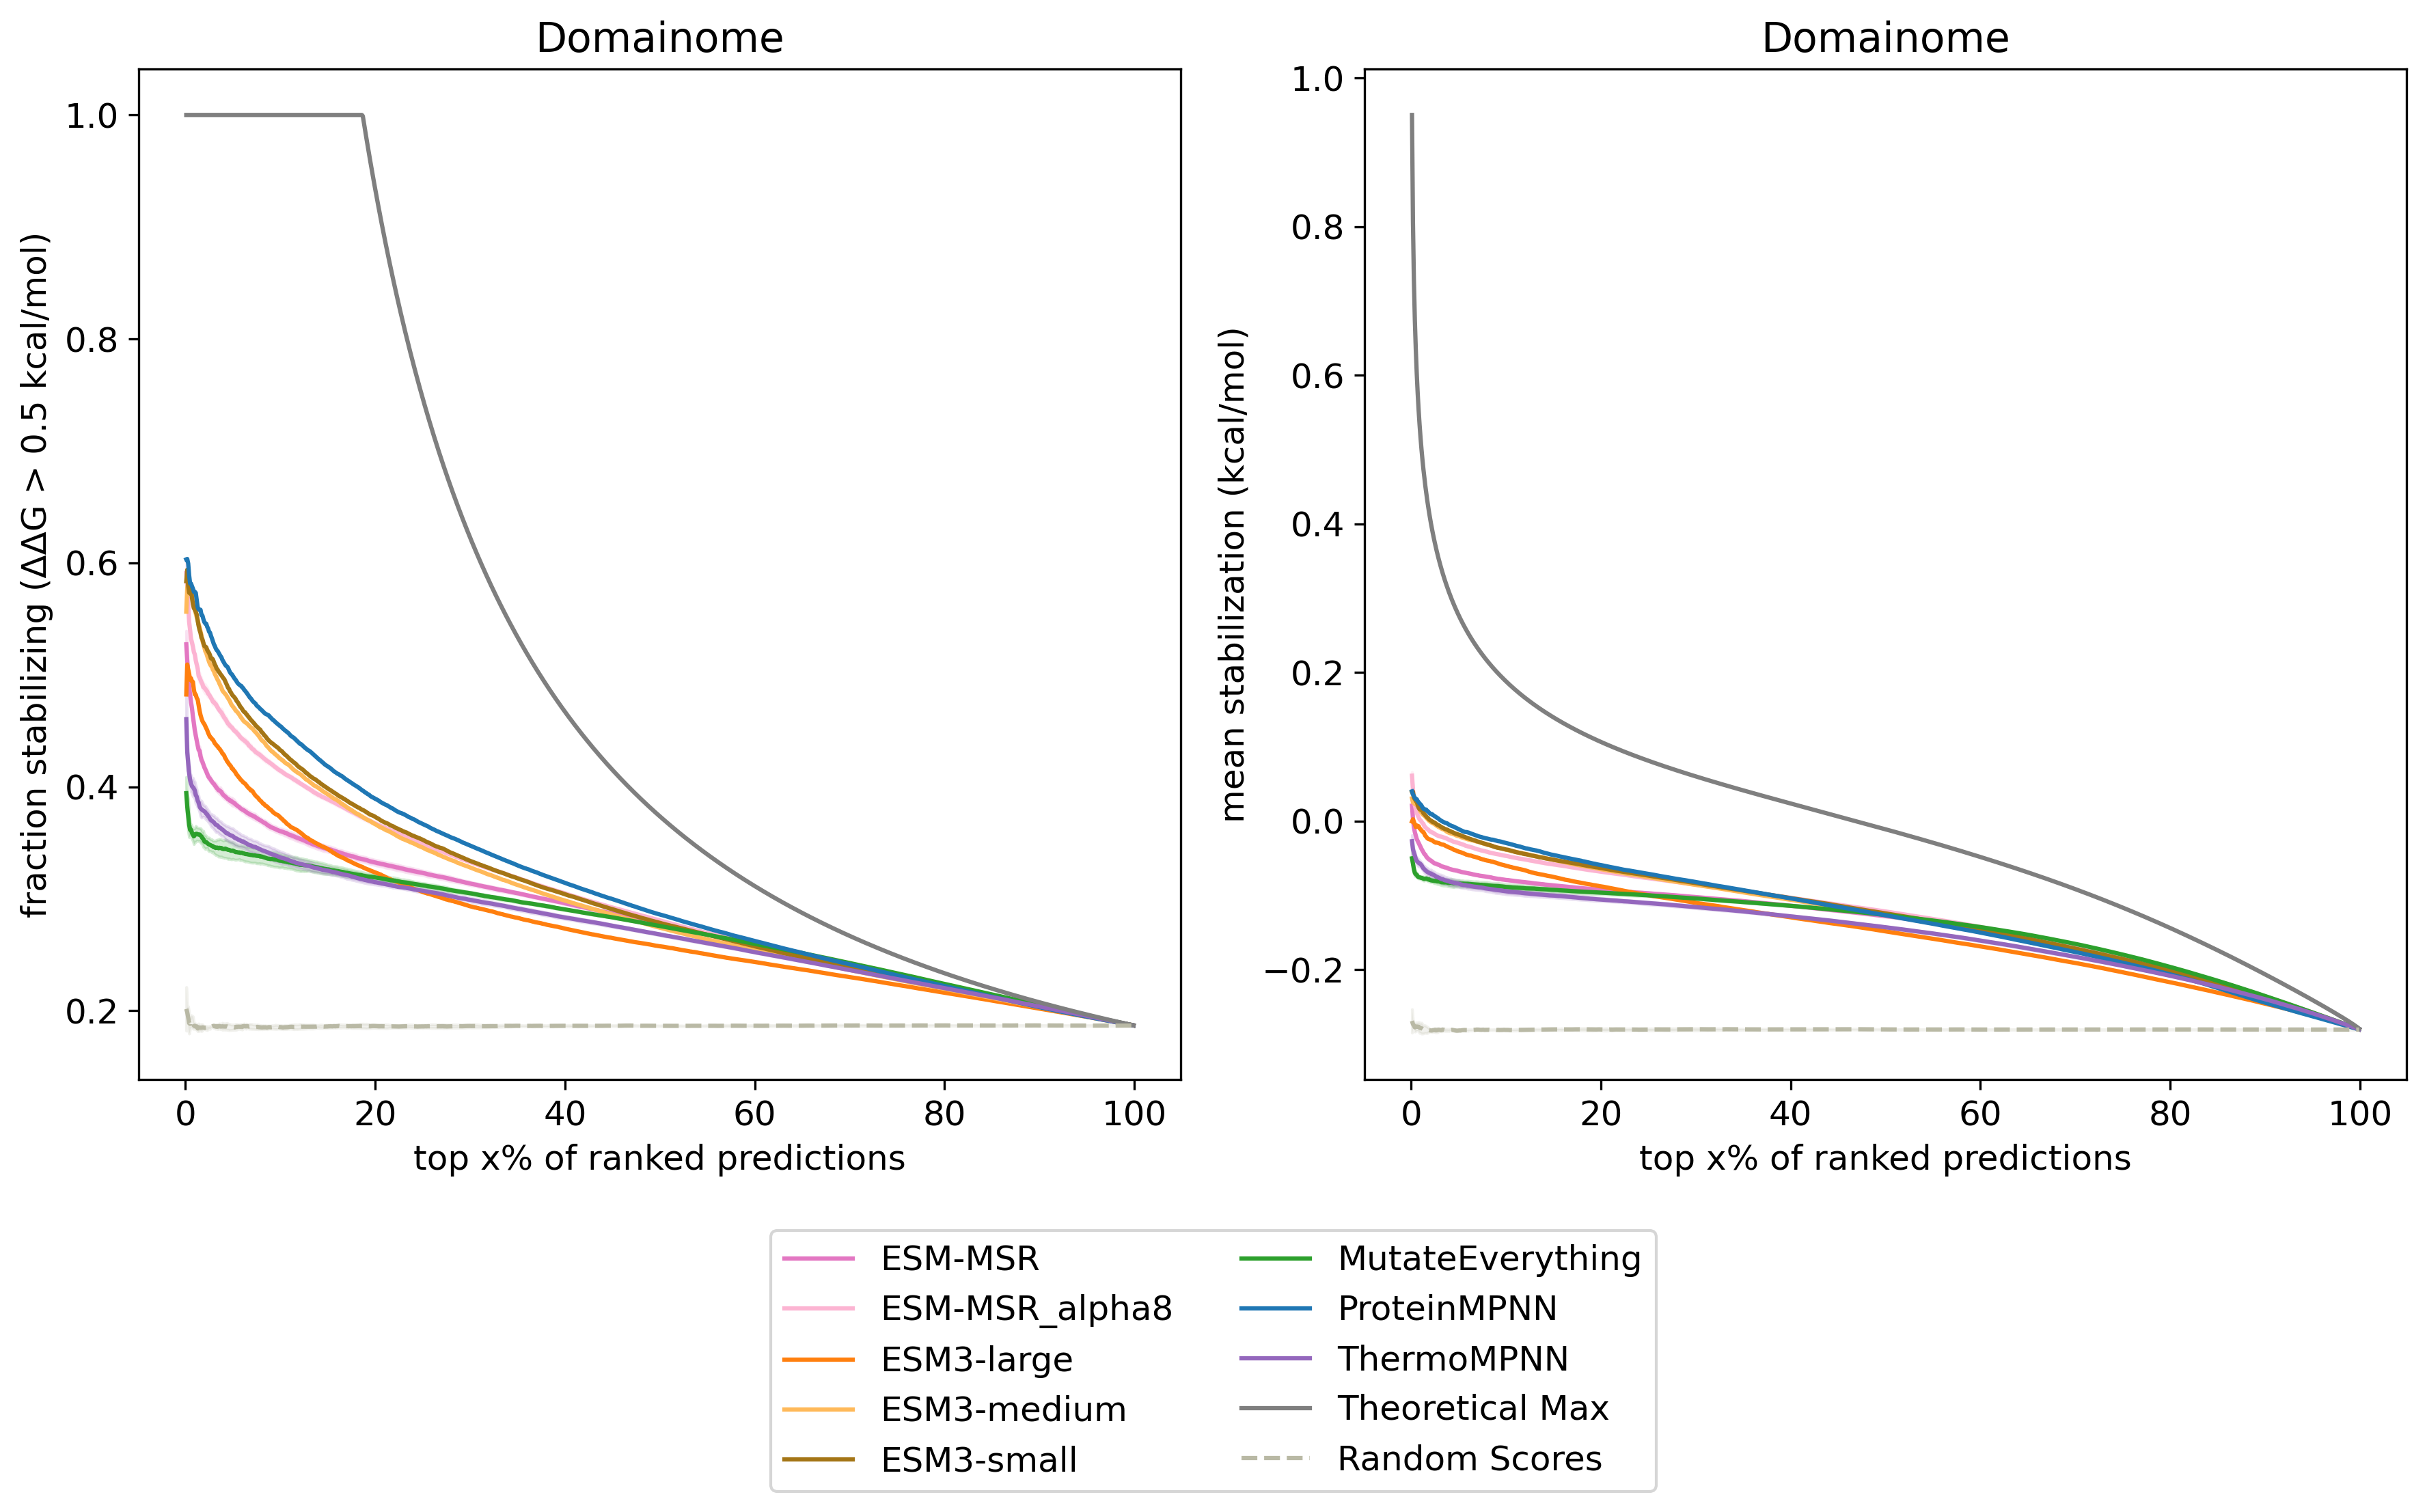

In [11]:
import importlib
import analysis_utils_msr
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import recovery_curves

df = curve_df_ungrouped.copy(deep=True).reset_index()
df['model'] = [c[:-4] for c in df['model'] if c.endswith('_dir')]
df = df.set_index(['measurement', 'model_type', 'model', 'class'])
fig = recovery_curves(df, ['ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 'ESM-MSR_alpha8_1', 'ESM-MSR_alpha8_2', 'ESM-MSR_alpha8_3',
                            'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3', 
                            'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 
                            'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG', #'ESM3-small-open',  
                            'upper_bound', 'random', 'ProteinMPNN',
                            'random_1', 'random_2', 'random_3'], measurements=['ddG'], plots=['auppc', 'aumsc'], title='Domainome')

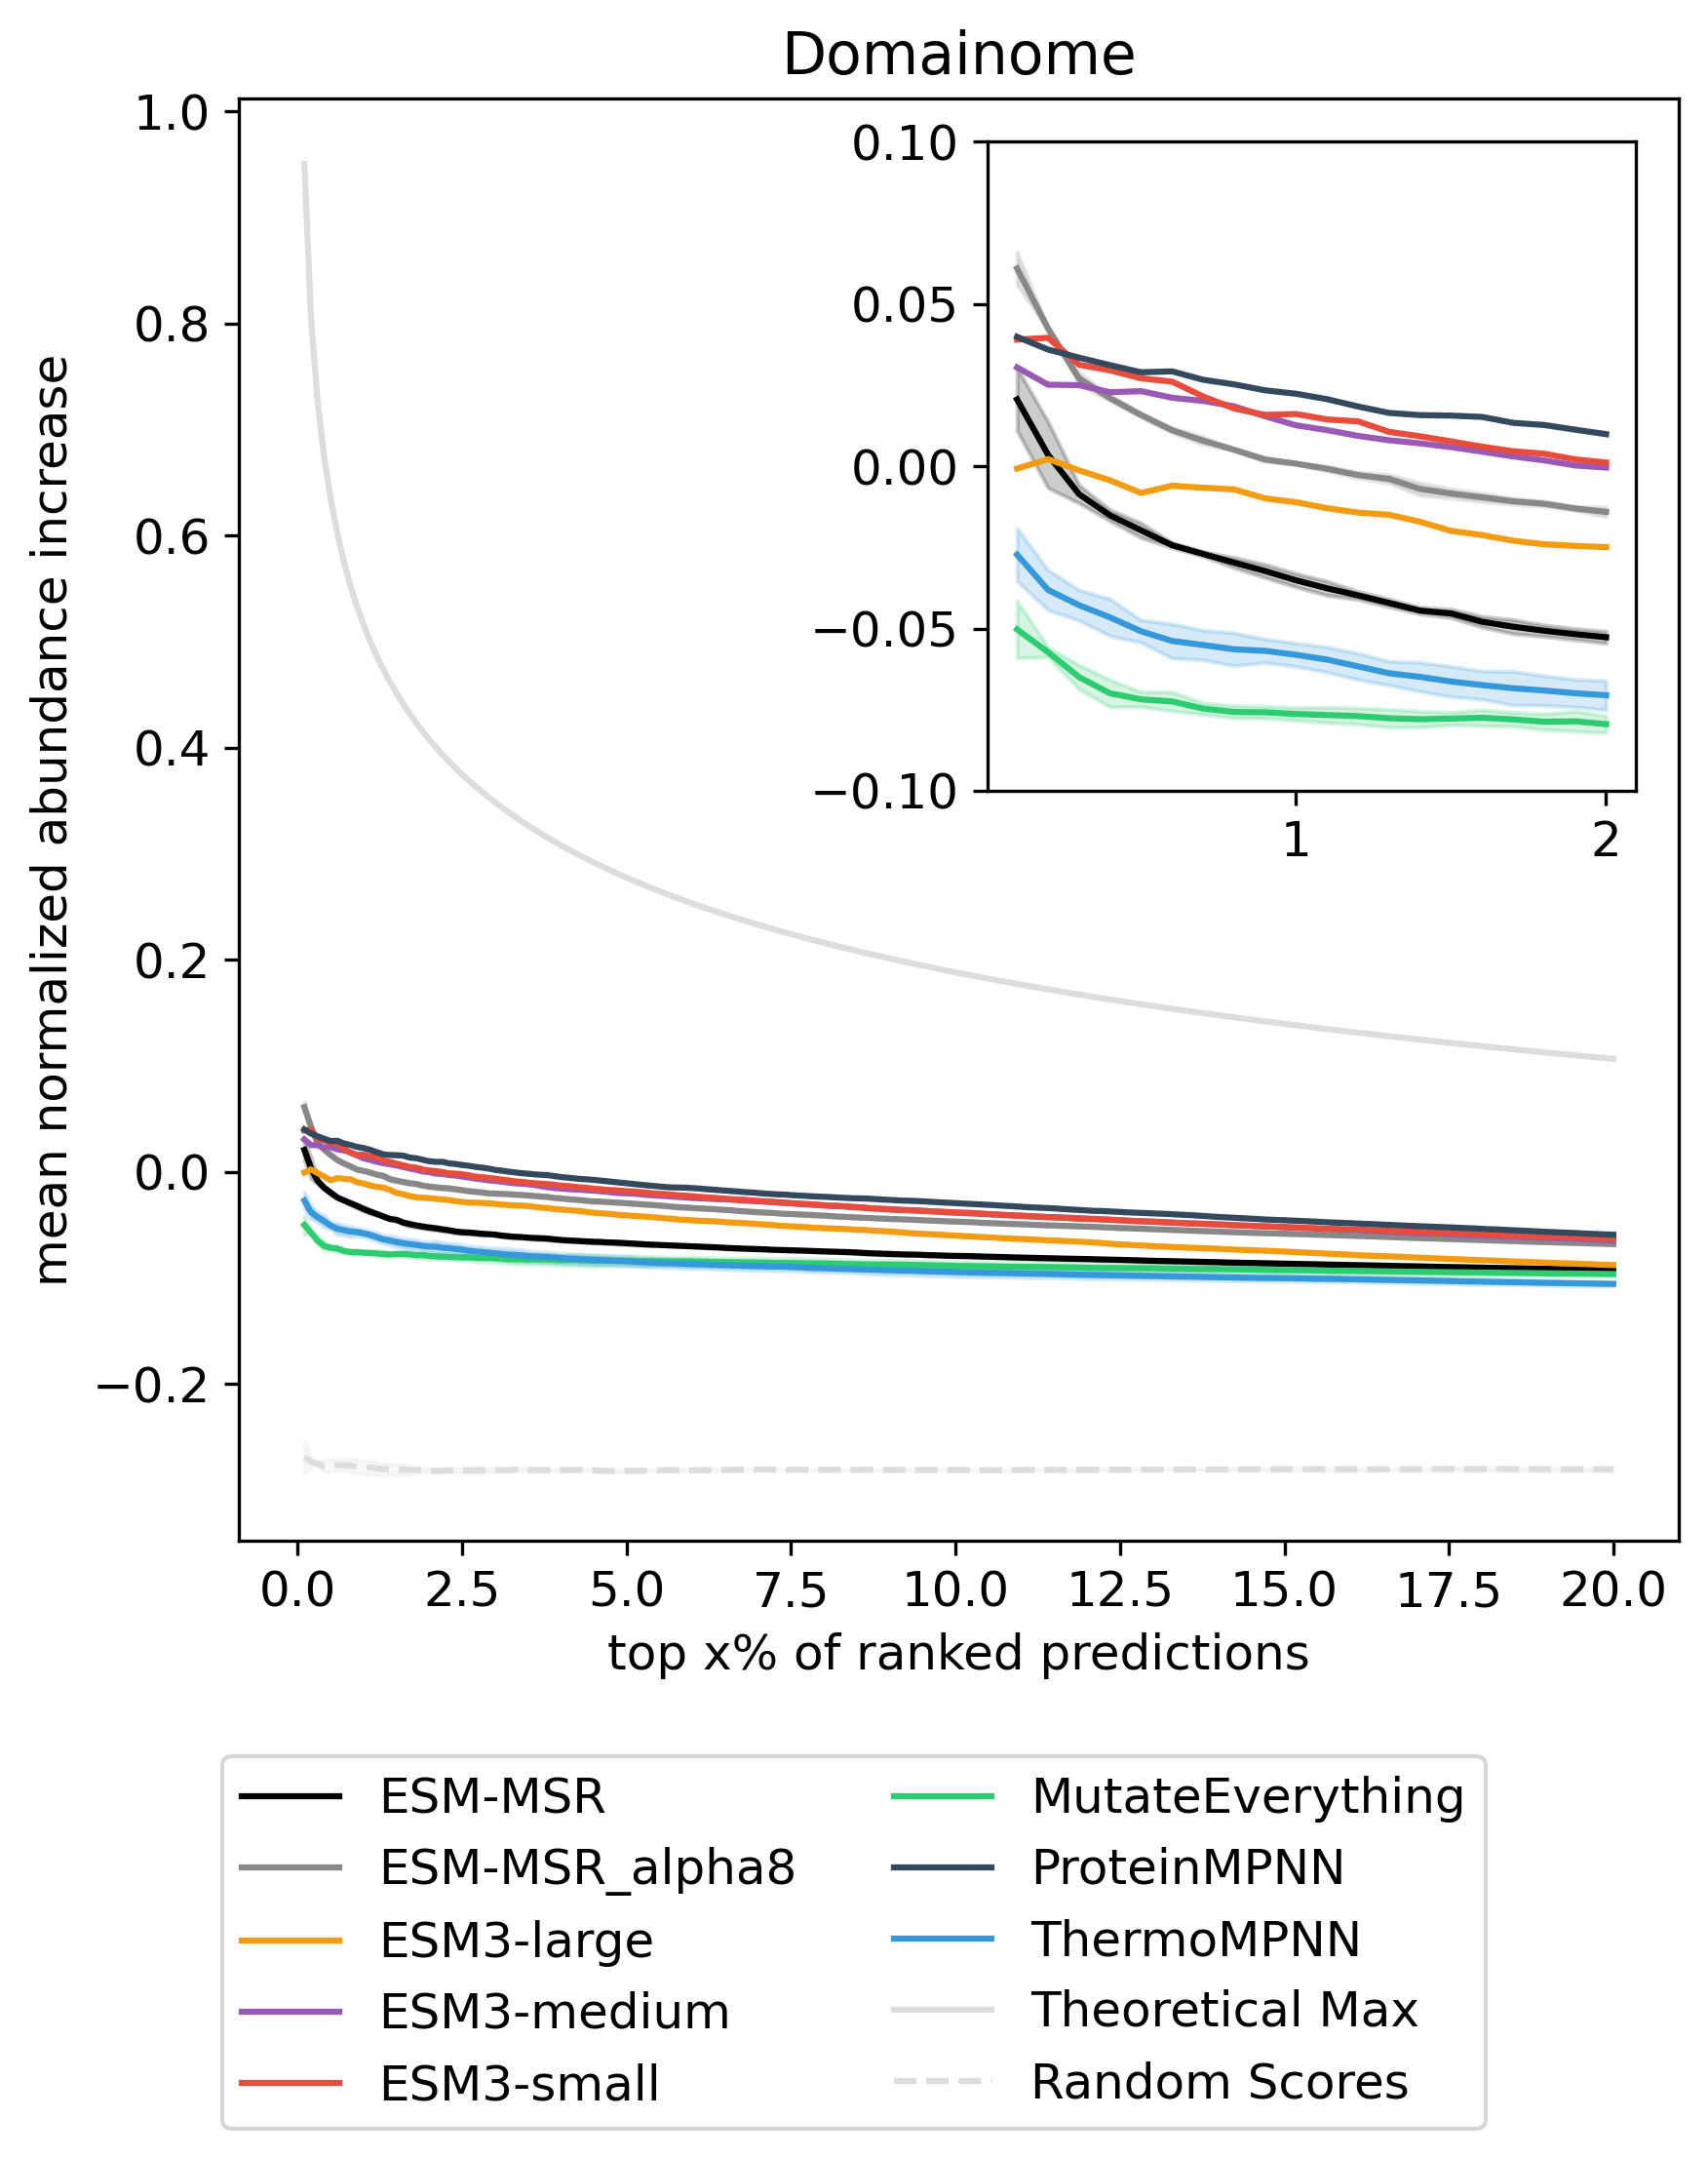

In [12]:
fig = recovery_curves_aumsc(df, ['ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 'ESM-MSR_alpha8_1', 'ESM-MSR_alpha8_2', 'ESM-MSR_alpha8_3',
                            'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3', 
                            'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 
                            'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG', #'ESM3-small-open', 
                            'upper_bound', 'random', 'ProteinMPNN',
                            'random_1', 'random_2', 'random_3'], measurements=['ddG'], title='Domainome',
                            range_full=(0,20), range_mag=(0,2), ins_ylim=(-0.1, 0.1))

{'ESM-MSR': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), 'ESM-MSR_alpha8': (0.9899427176361898, 0.7049211603598974, 0.8225918660182985), 'ESM3-large': (1.0, 0.4980392156862745, 0.054901960784313725), 'ESM3-medium': (1.0, 0.7258134136044577, 0.34937220016014536), 'ESM3-small': (0.643648132712171, 0.45921290515410135, 0.08082684463604409), 'ESM3-small-open': (1.0, 0.723587611522641, 0.713842439535977), 'MutateEverything': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'ProteinMPNN': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'ThermoMPNN': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'upper_bound': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), 'random': (0.7265158293962721, 0.7265262613414029, 0.6464853211708125)}


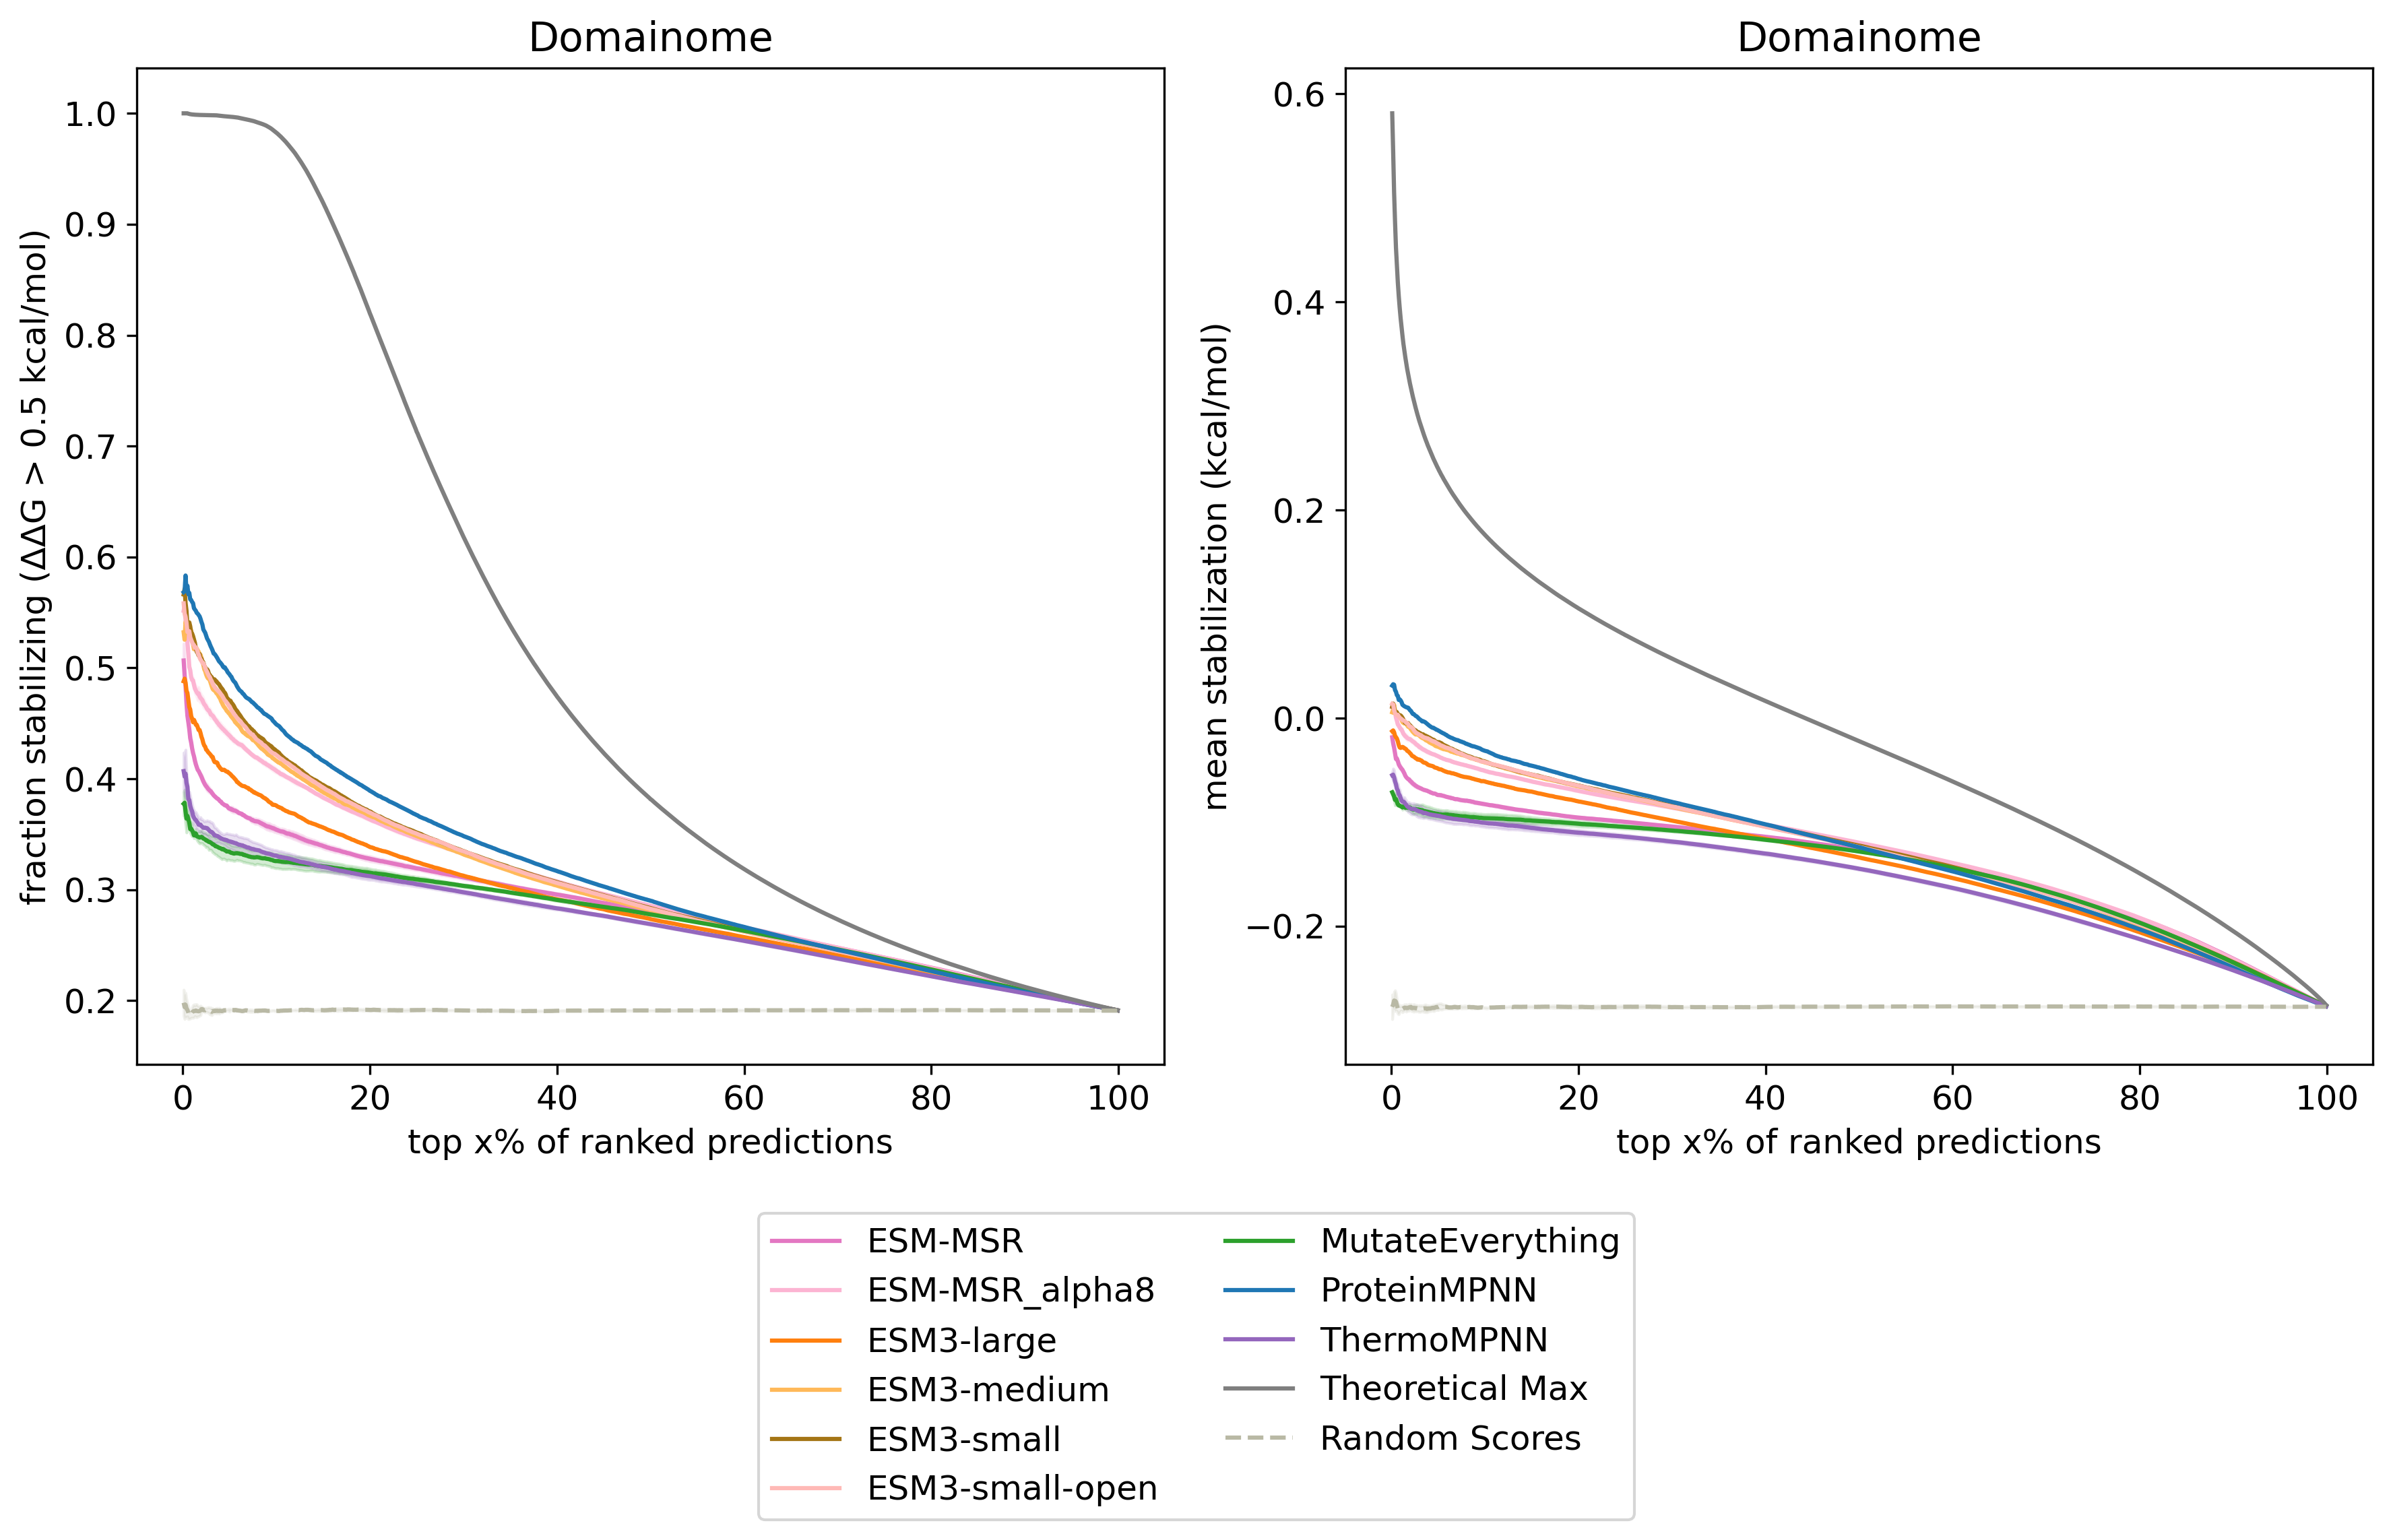

In [13]:
import importlib
import analysis_utils_msr
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import recovery_curves

df = curve_df_grouped.copy(deep=True).reset_index().iloc[:-1, :]
df['model'] = [c[:-4] for c in df['model'] if c.endswith('_dir')]
df = df.set_index(['measurement', 'model_type', 'model', 'class'])
fig = recovery_curves(df, ['ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 'ESM-MSR_alpha8_1', 'ESM-MSR_alpha8_2', 'ESM-MSR_alpha8_3',
                            'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3', 
                            'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 
                            'ESM3-small-open', 'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG', 
                            'upper_bound', 'random', 'ProteinMPNN',
                            'random_1', 'random_2', 'random_3'], measurements=['ddG'], plots=['auppc', 'aumsc'], title='Domainome')

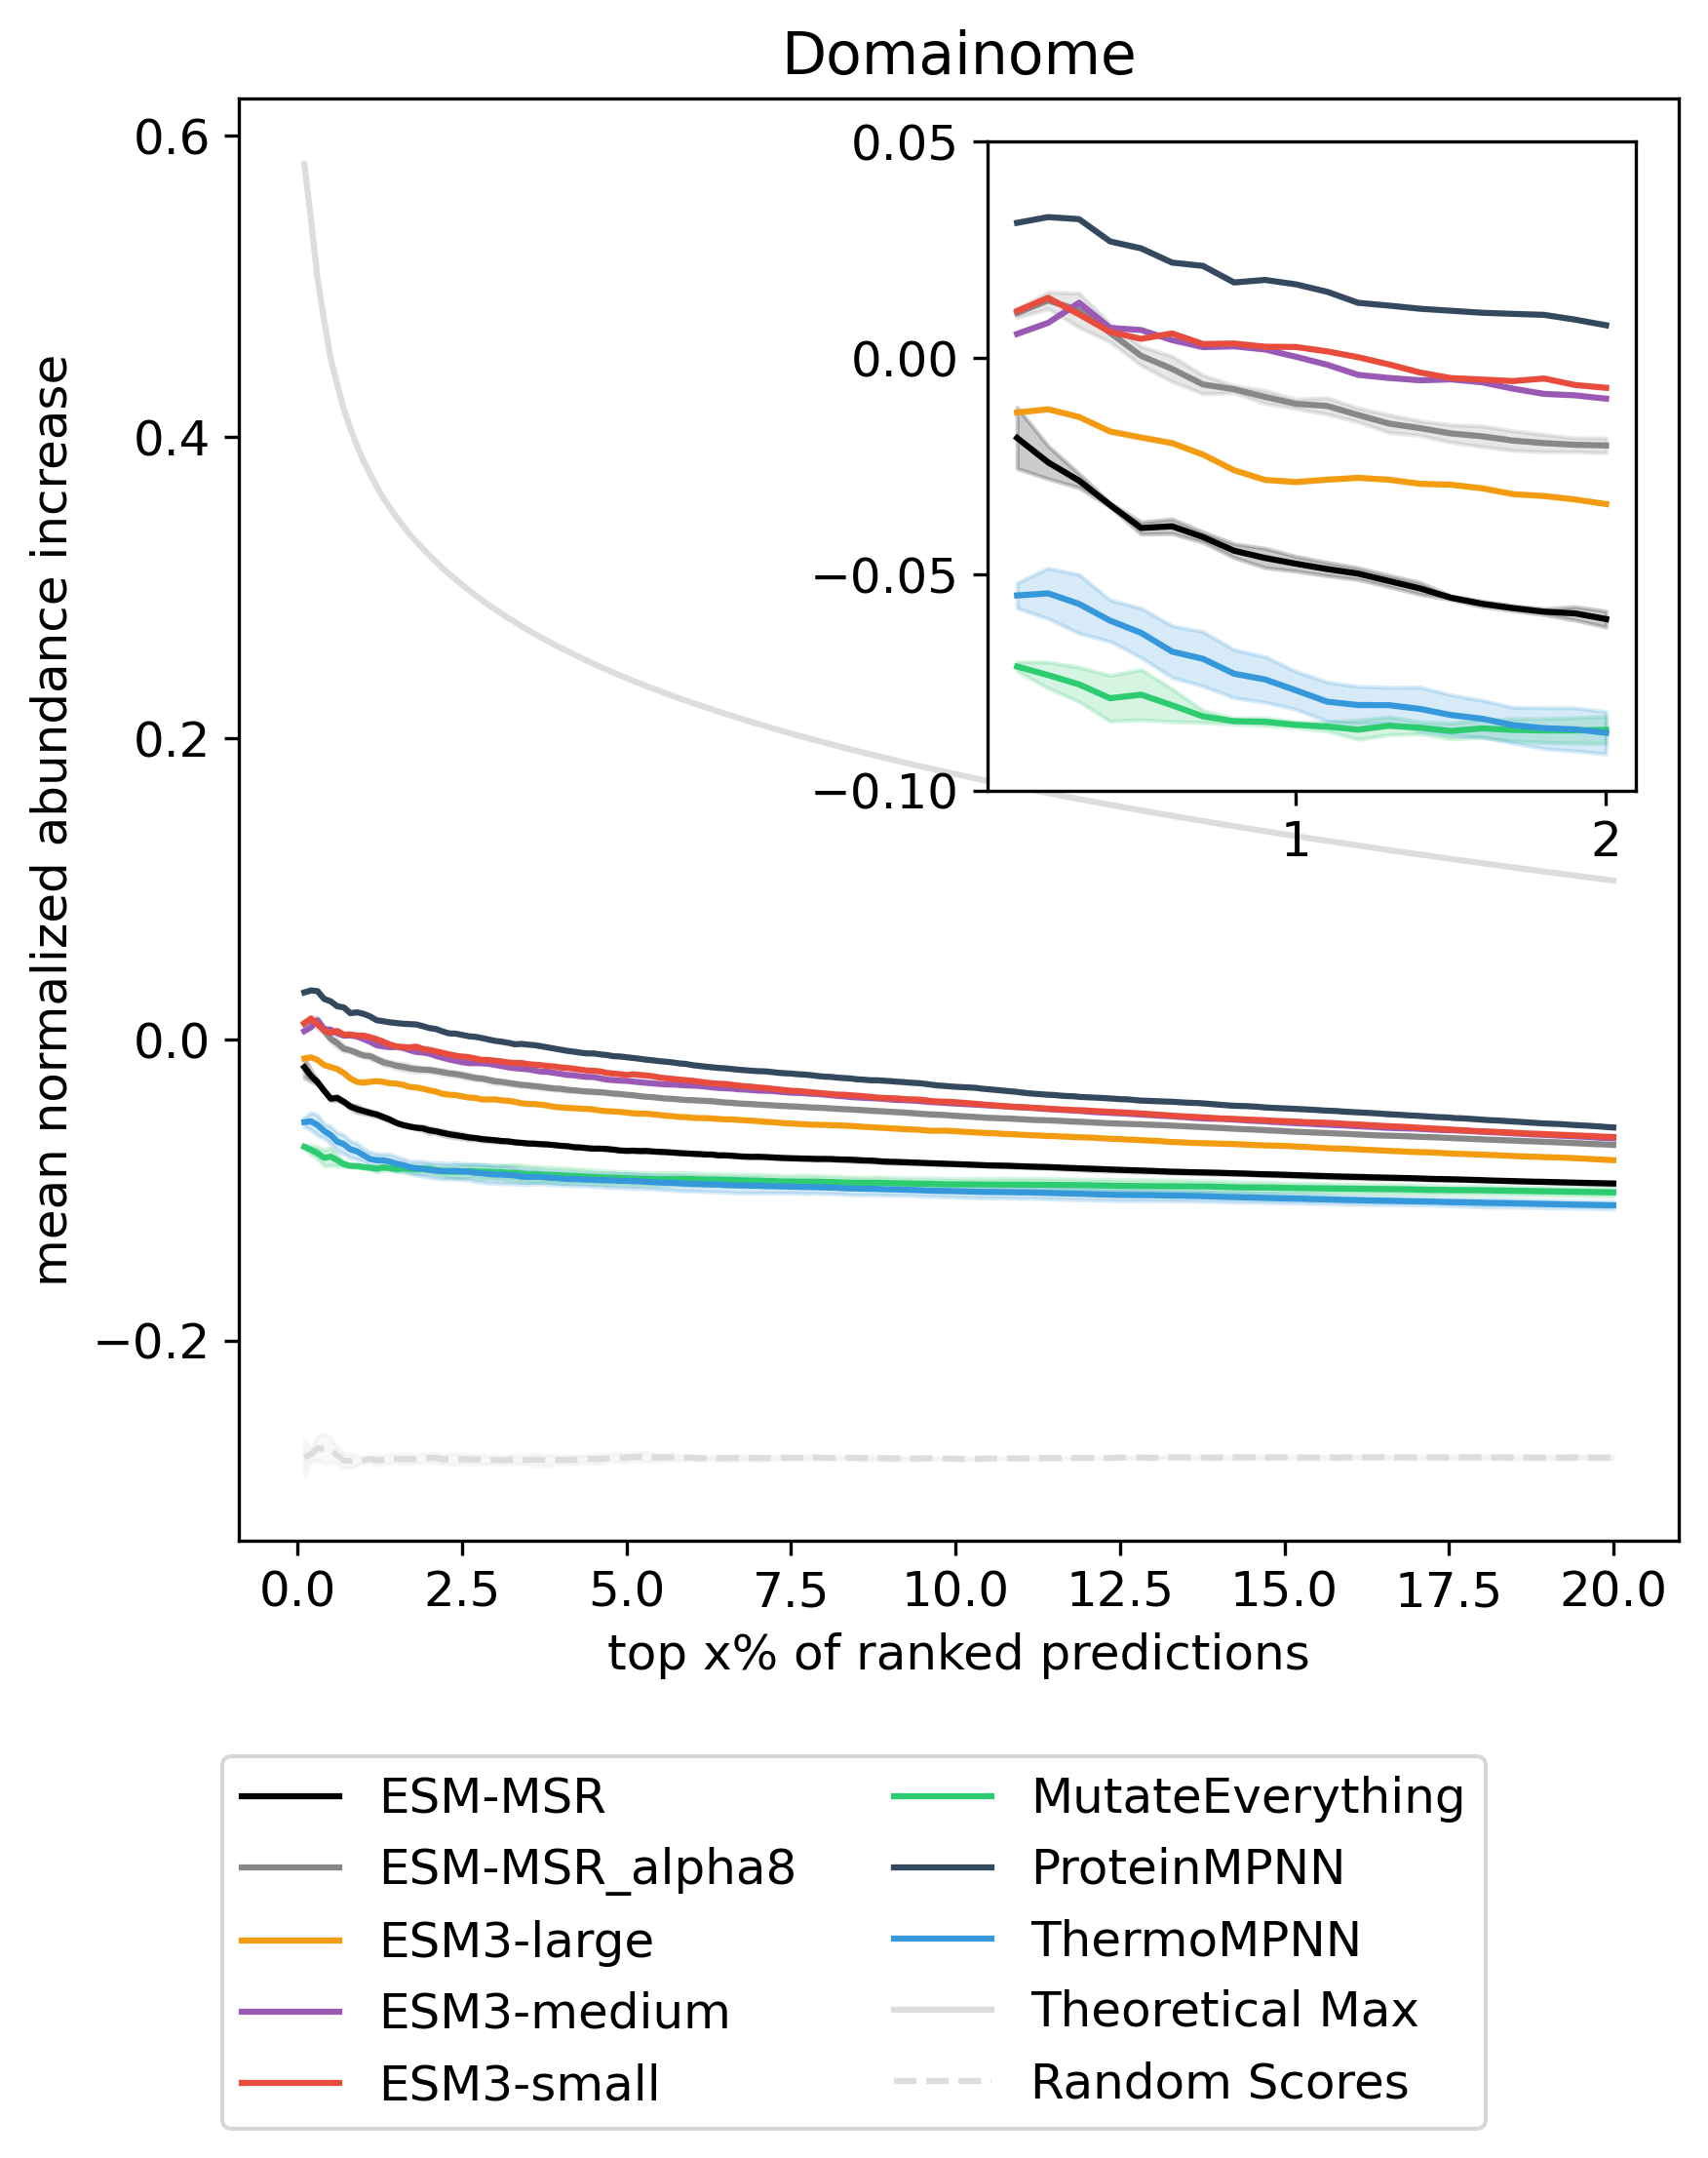

In [14]:
fig = recovery_curves_aumsc(df, ['ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 'ESM-MSR_alpha8_1', 'ESM-MSR_alpha8_2', 'ESM-MSR_alpha8_3',
                            'ThermoMPNN_1', 'ThermoMPNN_2', 'ThermoMPNN_3', 
                            'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 
                            'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG', #'ESM3-small-open', 
                            'upper_bound', 'random', 'ProteinMPNN',
                            'random_1', 'random_2', 'random_3'], measurements=['ddG'], title='Domainome',
                            range_full=(0,20), range_mag=(0,2), ins_ylim=(-0.1, 0.05))